# **1. Perkenalan Dataset**


# Eksperimen Model Titanic Survival

**Informasi Dataset:**
* **Nama Dataset:** Titanic: Machine Learning from Disaster
* **Sumber / Link:** [Kaggle - Titanic Dataset](https://www.kaggle.com/c/titanic/data)
* **Deskripsi Singkat:** Dataset ini berisi data penumpang kapal Titanic (seperti umur, jenis kelamin, kelas tiket). Tujuan dari eksperimen ini adalah untuk membangun model Machine Learning yang dapat memprediksi apakah seorang penumpang selamat (Survived) atau tidak berdasarkan fitur-fitur tersebut.

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
#Type your code here
# Memuat dataset Titanic langsung dari URL
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Menampilkan 5 baris pertama untuk ngecek data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Jumlah Data yang Kosong (Missing Values) ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fa

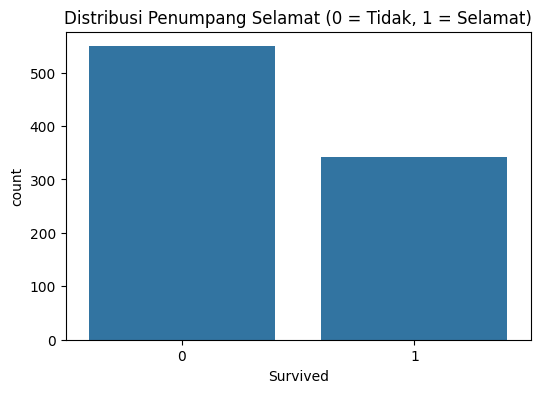

In [ ]:
#Type your code here
# 1. Melihat informasi tipe data dan jumlah missing value
print("--- Info Dataset ---")
df.info()

print("\n--- Jumlah Data yang Kosong (Missing Values) ---")
print(df.isnull().sum())

# 2. Bikin visualisasi jumlah penumpang yang selamat vs tidak
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title('Distribusi Penumpang Selamat (0 = Tidak, 1 = Selamat)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# 1. Hapus kolom yang tidak relevan buat prediksi dan kolom Cabin (karena terlalu banyak data kosong)
df_clean = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# 2. Tangani Data Kosong (Missing Values)
# Isi umur (Age) yang kosong dengan nilai tengah (median)
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
# Isi tempat berangkat (Embarked) yang kosong dengan nilai yang paling sering muncul (modus)
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# 3. Hapus data yang duplikat (jika ada)
df_clean = df_clean.drop_duplicates()

# 4. Encoding Data Kategorikal (Ubah teks jadi angka)
# Ubah jenis kelamin (Sex) jadi angka: male = 0, female = 1
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
# One-Hot Encoding untuk asal pelabuhan (Embarked)
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True)

# Cek hasil akhir dataset yang udah bersih!
print("\n--- Info Dataset Bersih ---")
df_clean.info()
df_clean.head()


--- Info Dataset Bersih ---
<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    775 non-null    int64  
 1   Pclass      775 non-null    int64  
 2   Sex         775 non-null    int64  
 3   Age         775 non-null    float64
 4   SibSp       775 non-null    int64  
 5   Parch       775 non-null    int64  
 6   Fare        775 non-null    float64
 7   Embarked_Q  775 non-null    bool   
 8   Embarked_S  775 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.0 KB


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True
